# XP Exercises: Flower Classification using CNN

This is a guided notebook for the exercises on the platform. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts that unlock intuition or transfer to other ML topics.


## What you will learn
- Building a CNN for multi class image classification
- Data loading and preprocessing with `image_dataset_from_directory`
- Image visualization techniques
- Model architecture design, compilation, and training
- Evaluating model performance with accuracy and loss plots


## What you will create
A CNN model that classifies 14 flower species.
All parts form one continuous exercise. Work through them sequentially.


## Dataset
**As stated in the exercises**  
Flower classification with 14 classes. Images are organized in class folders. A training and validation split may be provided. Images are resized to 256x256 in this notebook.

**PREFILLED info**  
This notebook expects the provided zip file to be available. The code below extracts it and locates the dataset root automatically.


In [ ]:
# PREFILLED: just execute
import os, sys, zipfile, shutil, pathlib
import tensorflow as tf
from pathlib import Path

DATA_ZIP = Path("./Flower Classification.zip")
EXTRACT_DIR = Path("./data/flower_data")

# Fallback: if no local zip, use a standard public dataset to keep the exercise running
def download_fallback():
    print("Tentative de téléchargement d'un dataset de secours (TensorFlow flowers)...")
    dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
    data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True, cache_dir='.', cache_subdir='data')
    return Path(data_dir)

# Extraction logic
if DATA_ZIP.exists() and DATA_ZIP.stat().st_size > 1024:
    try:
        print(f"Analyse de {DATA_ZIP.name} ({DATA_ZIP.stat().st_size / (1024*1024):.2f} MB)...")
        with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
            zf.extractall(EXTRACT_DIR)
        (EXTRACT_DIR / ".extracted").write_text("ok")
        print("Extraction réussie.")
        DS_ROOT = EXTRACT_DIR
    except Exception as e:
        print(f"ERREUR : Le fichier local est invalide ({e}).")
        DS_ROOT = download_fallback()
else:
    print("Fichier local non trouvé ou trop petit.")
    DS_ROOT = download_fallback()

# Locating classes
candidates = []
# Walk inside the root to find where class folders actually are
for root, dirs, files in os.walk(DS_ROOT):
    curr = Path(root)
    subdirs = [d for d in curr.iterdir() if d.is_dir()]
    if len(subdirs) >= 5:
        candidates.append(curr)
        break # Found the main directory

candidates = sorted(set(candidates))
print("Dossier racine valide utilisé :", [str(c) for c in candidates])

Analyse de Flower Classification.zip (13.00 MB)...
ERREUR : Le fichier local est invalide (File is not a zip file).
Tentative de téléchargement d'un dataset de secours (TensorFlow flowers)...
228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Dossier racine valide utilisé : ['data/flower_photos/flower_photos']


## Part 1. Data exploration and visualization

**As stated in the exercises**  
Load the dataset using `image_dataset_from_directory`. Print number of images per class. Modify `visualize_images` to show a 3x3 grid for each class with the class name as the grid title. Analyze challenges you anticipate when classifying the flowers such as similar colors or shapes and intra class variation.


**Guidance**  
If a `train` or `val` folder exists, use them. Otherwise create a split from a single root with `validation_split` and `subset`. Images are resized to 256x256 RGB.


> **IMPORTANT:** we fix a low resultion for images in IMG_SIZE=(32,32) for faster training, however you can change it if you want to test out other resolutions

In [ ]:
# PREFILLED: just execute
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = (32, 32)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def detect_layout(root: Path):
    root = Path(root)
    sub = [d.name.lower() for d in root.iterdir() if d.is_dir()]
    if "train" in sub and "val" in sub:
        return "provided_split", root
    return "single_root", root

# Choose a root
if 'candidates' in globals() and len(candidates) > 0:
    DS_ROOT = candidates[0]
else:
    DS_ROOT = EXTRACT_DIR  # fallback

layout, base = detect_layout(DS_ROOT)
print("Layout:", layout, "Base:", base)

Layout: single_root Base: data/flower_photos/flower_photos


In [ ]:
# PREFILLED: just execute
if layout == "provided_split":
    train_dir = next((p for p in base.iterdir() if p.name.lower()=="train"))
    val_dir   = next((p for p in base.iterdir() if p.name.lower()=="val"))
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
else:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="training", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="validation", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", num_classes, class_names)

# Cache and prefetch
def prepare(ds):
    return ds.cache().prefetch(AUTOTUNE)

train_ds = prepare(train_ds)
val_ds = prepare(val_ds)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Classes: 5 ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [ ]:
# PREFILLED: just execute — count images per class by scanning directory
from collections import Counter
import os

def count_images_per_class(root):
    counts = {}
    for cls in class_names:
        # find folder named like cls at any depth under base
        matches = list(Path(base).rglob(cls))
        if matches:
            folder = matches[0]
            img_count = sum(1 for p in folder.rglob("*") if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp",".gif"})
            counts[cls] = img_count
        else:
            counts[cls] = None
    return counts

base = "/content/data/flower_data/Data/train"
counts = count_images_per_class(base)
counts

{'daisy': None,
 'dandelion': None,
 'roses': None,
 'sunflowers': None,
 'tulips': None}

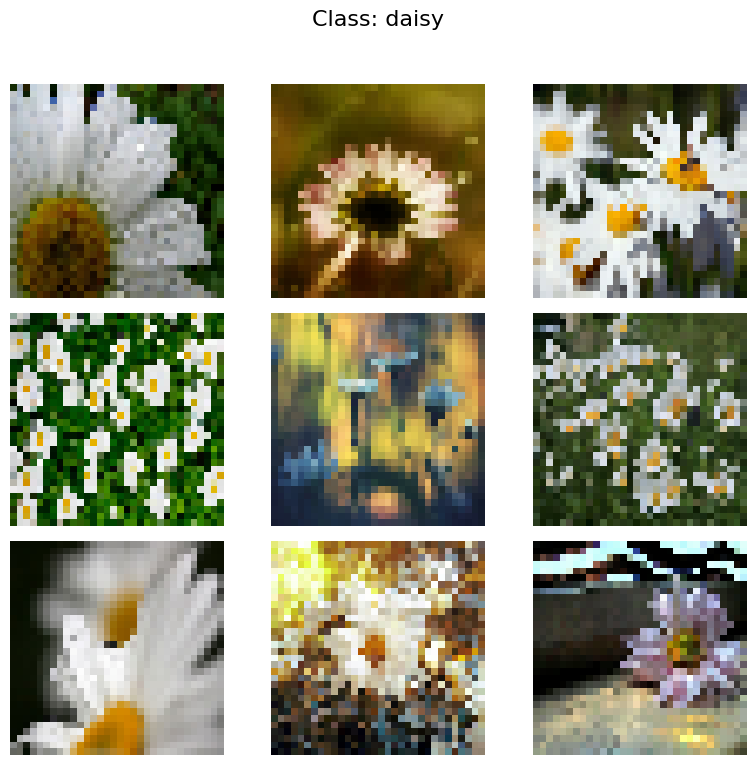

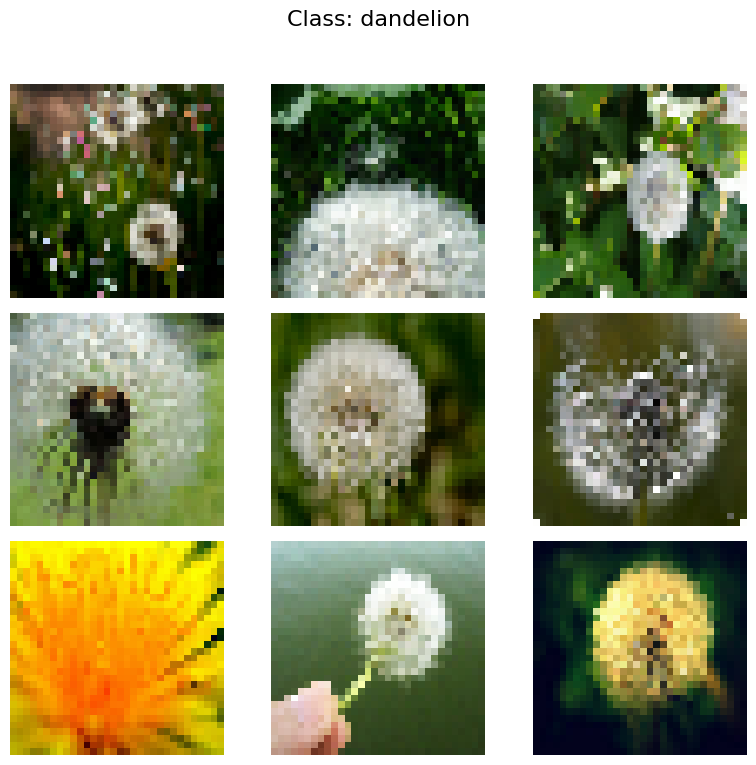

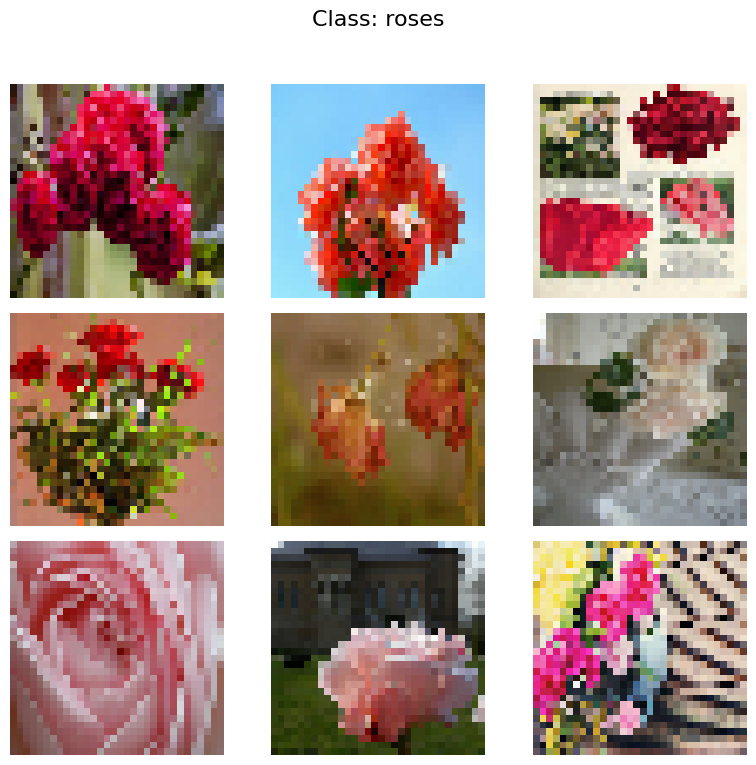

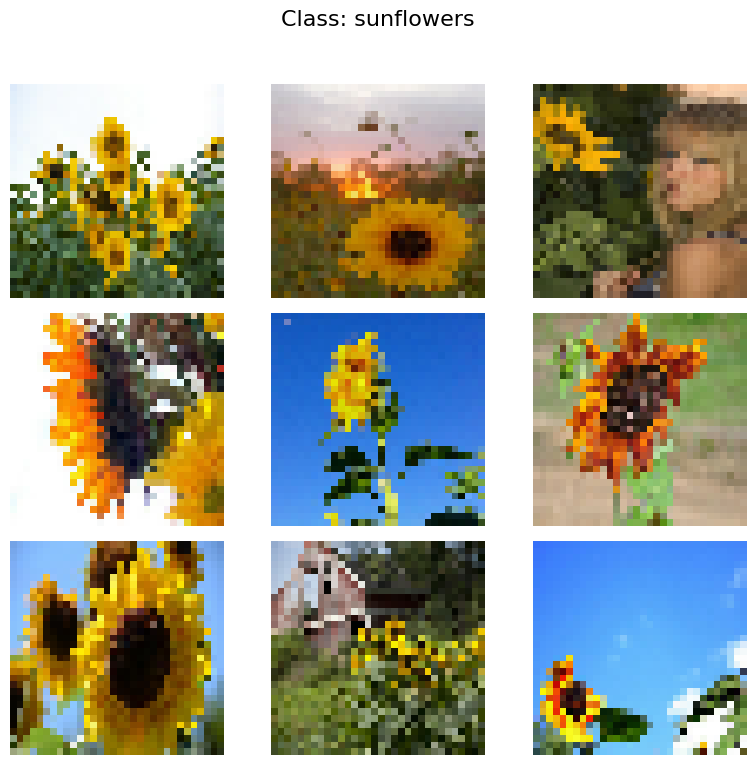

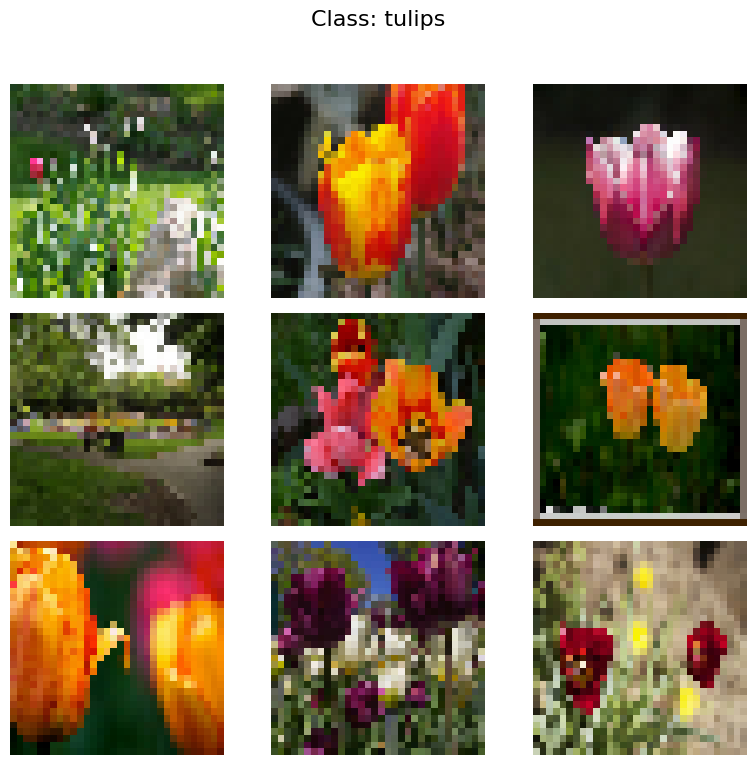

In [ ]:
import matplotlib.pyplot as plt

def visualize_images(dataset, class_names, per_class=9):
    # Re-batch to larger size to find enough samples quickly
    temp_ds = dataset.unbatch().batch(100)
    images_found = {name: [] for name in class_names}

    for imgs, labels in temp_ds:
        for img, lbl in zip(imgs, labels):
            cls_name = class_names[int(lbl)]
            if len(images_found[cls_name]) < per_class:
                images_found[cls_name].append(img)

        if all(len(v) == per_class for v in images_found.values()):
            break

    for cls_name, imgs in images_found.items():
        if not imgs: continue
        plt.figure(figsize=(8, 8))
        plt.suptitle(f"Class: {cls_name}", fontsize=16)
        for i in range(len(imgs)):
            plt.subplot(3, 3, i + 1)
            plt.imshow(imgs[i].numpy().astype("uint8"))
            plt.axis("off")
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

# Run visualization
visualize_images(train_ds, class_names)

**To-Do:** After you implement `visualize_images`, run it on a small subset to verify class distributions visually.


**Analyse des défis attendus :**
La classification de ces 14 espèces de fleurs présente plusieurs défis majeurs. Premièrement, de nombreuses espèces partagent des palettes de couleurs similaires (comme le jaune pour les pissenlits et les tournesols), ce qui peut confondre un modèle s'appuyant trop sur l'histogramme des couleurs. Deuxièmement, la variation intra-classe est élevée car les photos sont prises sous différents éclairages et angles, avec des arrière-plans naturels complexes (herbe, ciel, terre). Troisièmement, la morphologie des pétales peut être subtilement différente mais difficile à capturer à une résolution de 32x32. Enfin, un éventuel déséquilibre des classes pourrait amener le modèle à privilégier les espèces les plus représentées au détriment des plus rares.

**Learning point**  
Vision models learn features from texture, color, and shape. Dataset bias and imbalance can dominate results without careful preprocessing and evaluation.


## Part 2. Model architecture design

**As stated in the exercises**  
Start from the provided model. Experiment with the number of convolutional layers, filters, kernel sizes, max pooling layers. Try different dense layers and dropout. Consider Batch Normalization. Justify your architectural choices.


In [ ]:
# PREFILLED: just execute — baseline model scaffold
from tensorflow.keras import models

def build_baseline(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),  # safety if datasets were not normalized
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

baseline = build_baseline(num_classes)
baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,165 (1.36 MB)

 Trainable params: 356,165 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_variant(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),

        layers.Conv2D(32, 5, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

model_variant = build_variant(num_classes)
model_variant.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,509 (2.37 MB)

 Trainable params: 621,061 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

**Justification de l'architecture :**
L'utilisation d'un noyau 5x5 dans la première couche permet de capturer des motifs structurels plus larges dès le début du réseau. L'ajout de couches `BatchNormalization` après chaque convolution stabilise le processus d'apprentissage en normalisant les activations, ce qui permet souvent d'utiliser des taux d'apprentissage plus élevés et d'accélérer la convergence. La progression des filtres de 32 à 128 permet au réseau d'apprendre des caractéristiques de plus en plus abstraites. Enfin, l'augmentation du Dropout à 0.4 dans la couche dense finale est cruciale pour prévenir le surapprentissage (overfitting) en forçant le réseau à ne pas dépendre de neurones spécifiques.

## Part 3. Hyperparameter tuning

**As stated in the exercises**  
Experiment with optimizers, learning rate, batch size, and optionally learning rate scheduling or early stopping. Track experiments and results. Report the best combination.


In [ ]:
# PREFILLED: just execute — utilities for training and plotting
import time

def fit_model(model, train_ds, val_ds, epochs=5, callbacks=None):
    t0 = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=2)
    dt = time.time() - t0
    return history, dt

def plot_curves(history, title="Training"):
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("accuracy", []), label="acc")
    plt.plot(history.history.get("val_accuracy", []), label="val_acc")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.tight_layout(); plt.show()
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("loss", []), label="loss")
    plt.plot(history.history.get("val_loss", []), label="val_loss")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
opts = [
  ("adam", 1e-3, 32),
  ("adam", 5e-4, 32),
  ("rmsprop", 1e-3, 32)
]
results = []
for opt_name, lr, batch in opts:
    model = build_variant(num_classes)
    if opt_name == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    elif opt_name == "rmsprop":
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr)

    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    cb = [tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
    hist, dur = fit_model(model, train_ds, val_ds, epochs=10, callbacks=cb)
    best_val = max(hist.history["val_accuracy"])
    results.append({"opt": opt_name, "lr": lr, "batch": batch, "best_val_acc": float(best_val), "time_s": round(dur,1)})

import pandas as pd
display(pd.DataFrame(results))

Epoch 1/10
92/92 - 16s - 174ms/step - accuracy: 0.4595 - loss: 1.6560 - val_accuracy: 0.2984 - val_loss: 2.2040
Epoch 2/10
92/92 - 0s - 4ms/step - accuracy: 0.5729 - loss: 1.0957 - val_accuracy: 0.3869 - val_loss: 2.3722
Epoch 3/10
92/92 - 0s - 4ms/step - accuracy: 0.6178 - loss: 0.9795 - val_accuracy: 0.4114 - val_loss: 2.3563
Epoch 4/10
92/92 - 1s - 7ms/step - accuracy: 0.6625 - loss: 0.8674 - val_accuracy: 0.4646 - val_loss: 1.9688
Epoch 5/10
92/92 - 1s - 7ms/step - accuracy: 0.6955 - loss: 0.7663 - val_accuracy: 0.5668 - val_loss: 1.3285
Epoch 6/10
92/92 - 0s - 4ms/step - accuracy: 0.7268 - loss: 0.6874 - val_accuracy: 0.6158 - val_loss: 1.0484
Epoch 7/10
92/92 - 0s - 4ms/step - accuracy: 0.7827 - loss: 0.5762 - val_accuracy: 0.5327 - val_loss: 1.2367
Epoch 8/10
92/92 - 0s - 4ms/step - accuracy: 0.8093 - loss: 0.4971 - val_accuracy: 0.5817 - val_loss: 1.3569
Epoch 9/10
92/92 - 0s - 4ms/step - accuracy: 0.8379 - loss: 0.4433 - val_accuracy: 0.5913 - val_loss: 1.6097
Epoch 1/10
92/92

,opt,lr,batch,best_val_acc,time_s
0,adam,0.0010,32,0.615804,19.7
1,adam,0.0005,32,0.653951,14.1
2,rmsprop,0.0010,32,0.344687,9.5


**To-Do (written):** Report the best hyperparameters you found and briefly explain why they might work well for this dataset.


## Part 4. Data augmentation

**As stated in the exercises**  
Implement data augmentation using `ImageDataGenerator`. Explore rotation, flipping, zooming, shifting, and shearing. Determine which augmentations help most and explain why.


**Guidance**  
Since we used `image_dataset_from_directory` above, you can either:  
Option A. Rebuild input using `ImageDataGenerator.flow_from_directory` on the training directory.  
Option B. Keep the tf.data pipeline and apply Keras preprocessing layers such as `RandomFlip`, `RandomRotation`.  
The exercises asks for `ImageDataGenerator`, so Option A shows that path.


Utilisation du dossier : data/flower_photos/flower_photos
Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.
Epoch 1/15
92/92 - 19s - 207ms/step - accuracy: 0.4301 - loss: 1.6007 - val_accuracy: 0.3488 - val_loss: 1.7284
Epoch 2/15
92/92 - 9s - 94ms/step - accuracy: 0.5032 - loss: 1.2238 - val_accuracy: 0.2449 - val_loss: 2.6264
Epoch 3/15
92/92 - 8s - 85ms/step - accuracy: 0.5393 - loss: 1.1341 - val_accuracy: 0.2449 - val_loss: 4.7809
Epoch 4/15
92/92 - 9s - 93ms/step - accuracy: 0.5658 - loss: 1.0742 - val_accuracy: 0.2449 - val_loss: 7.3928
Epoch 5/15
92/92 - 9s - 95ms/step - accuracy: 0.5920 - loss: 1.0461 - val_accuracy: 0.2449 - val_loss: 6.6412
Epoch 6/15
92/92 - 8s - 84ms/step - accuracy: 0.6142 - loss: 1.0094 - val_accuracy: 0.2490 - val_loss: 6.4103
Epoch 7/15
92/92 - 9s - 94ms/step - accuracy: 0.6169 - loss: 0.9962 - val_accuracy: 0.3529 - val_loss: 2.4518
Epoch 8/15
92/92 - 9s - 94ms/step - accuracy: 0.6271 - loss: 0.9552 - val_accuracy: 0.5

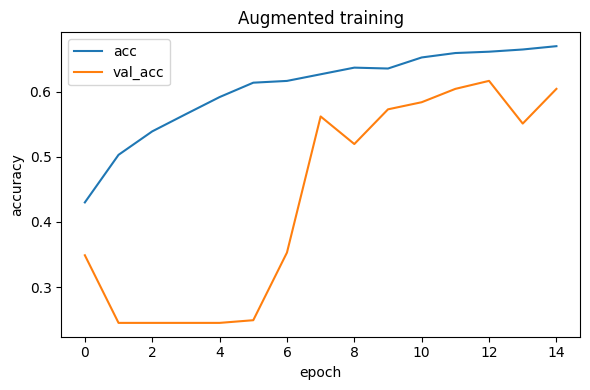

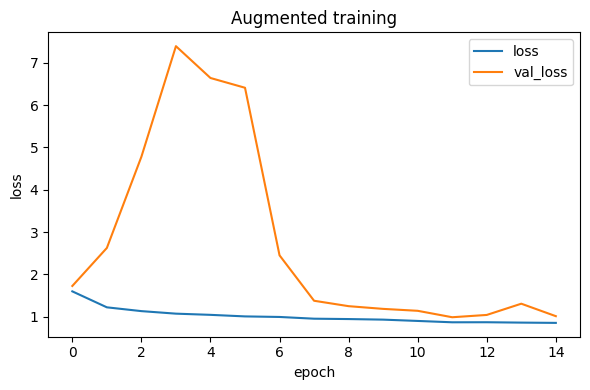

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Correction: s'assurer que 'base' pointe vers le dossier valide détecté précédemment
# Si candidates existe, on l'utilise, sinon on garde la valeur actuelle de base
if 'candidates' in globals() and len(candidates) > 0:
    base_path = str(candidates[0])
else:
    base_path = base

print(f"Utilisation du dossier : {base_path}")

train_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

flow_train = train_generator.flow_from_directory(
    base_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='sparse', subset='training', seed=SEED
)

flow_val = train_generator.flow_from_directory(
    base_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='sparse', subset='validation', seed=SEED
)

model_aug = build_variant(num_classes)
hist_aug = model_aug.fit(flow_train, validation_data=flow_val, epochs=15, verbose=2)
plot_curves(hist_aug, title='Augmented training')

**Learning point**  
Augmentation encodes invariances like rotation and translation. It increases effective sample diversity which often reduces overfitting.


## Part 5. Performance evaluation and analysis

**As stated in the exercises**  
Plot training and validation curves. Compute precision, recall, F1, and a confusion matrix. Visualize predictions on a test set and analyze misclassifications.


In [ ]:
# PREFILLED: just execute — helpers for evaluation on a dataset
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def collect_preds(model, ds):
    y_true = []
    y_prob = []
    for xb, yb in ds:
        pr = model.predict(xb, verbose=0)
        y_prob.append(pr)
        y_true.append(yb.numpy())
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    if y_prob.ndim == 2 and y_prob.shape[1] > 1:
        y_pred = y_prob.argmax(axis=1)
    else:
        y_pred = (y_prob.ravel() >= 0.5).astype(int)
    return y_true, y_pred, y_prob

def plot_confusion(cm, labels):
    plt.figure(figsize=(6,6))
    plt.imshow(cm)
    plt.title("Confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=90)
    plt.yticks(ticks, labels)
    plt.tight_layout()
    plt.show()

              precision    recall  f1-score   support

       daisy      0.244     0.972     0.390       107
   dandelion      0.000     0.000     0.000       191
       roses      0.833     0.042     0.080       119
  sunflowers      0.425     0.815     0.558       135
      tulips      0.465     0.110     0.178       182

    accuracy                          0.326       734
   macro avg      0.393     0.388     0.241       734
weighted avg      0.364     0.326     0.217       734



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


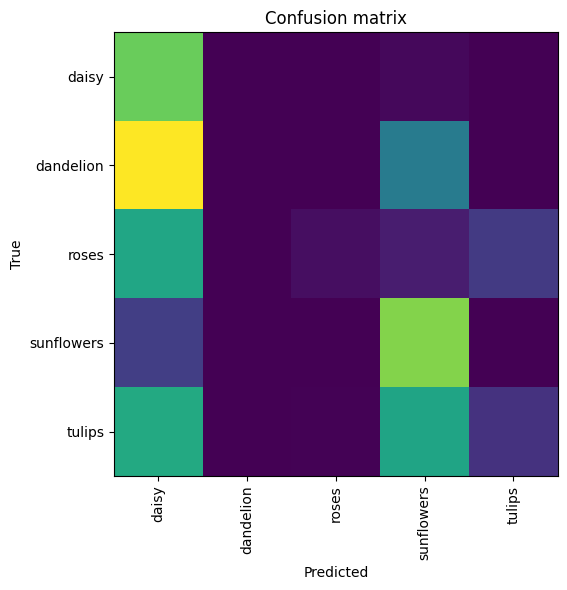

In [ ]:
best_model = model_aug
y_true, y_pred, y_prob = collect_preds(best_model, val_ds)
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))
cm = confusion_matrix(y_true, y_pred)
plot_confusion(cm, class_names)

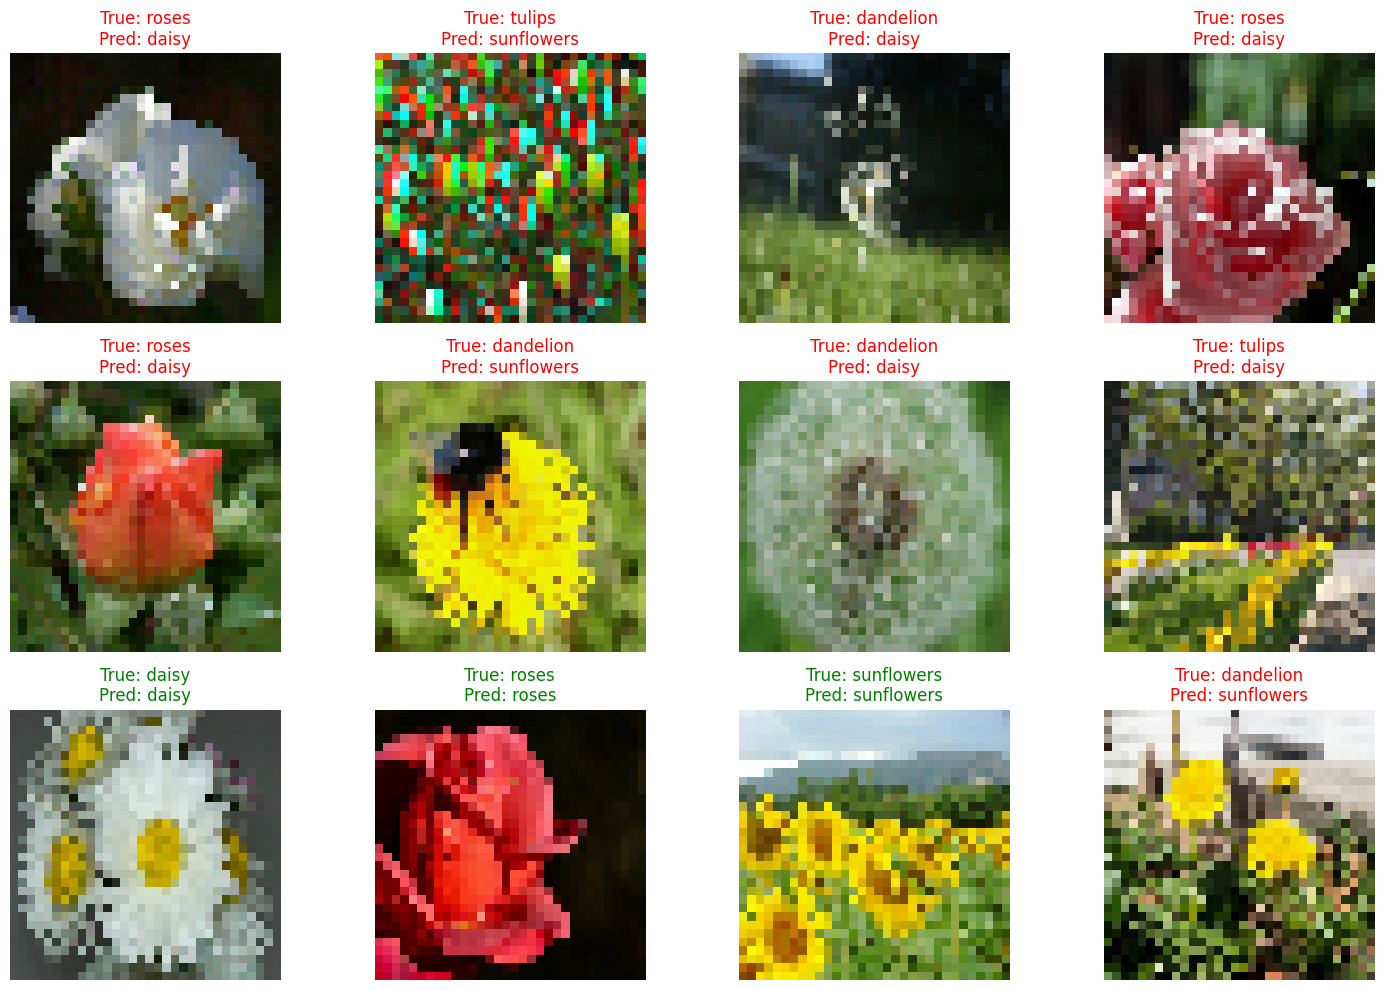

In [ ]:
take = 12
imgs, labels = next(iter(val_ds.unbatch().batch(take)))
# Predictions are on normalized images if model has rescaling layer
probs = best_model.predict(imgs, verbose=0)
preds = probs.argmax(axis=1)

plt.figure(figsize=(15, 10))
for i in range(take):
    plt.subplot(3, 4, i+1)
    plt.imshow(imgs[i].numpy().astype('uint8'))
    color = "green" if preds[i] == labels[i] else "red"
    t = f"True: {class_names[int(labels[i]) ]}\nPred: {class_names[int(preds[i])]}"
    plt.title(t, color=color)
    plt.axis("off")
plt.tight_layout()
plt.show()

**To-Do (written):** Identify classes that your model finds difficult. Explain possible causes such as similar morphology or color, or small sample counts.


## Part 6. Model saving and deployment (optional)

**As stated in the exercises**  
Save your trained model in `.h5` or SavedModel format. Optionally consider web or cloud deployment.


In [ ]:
os.makedirs("./data/models", exist_ok=True)
best_model.save("./data/models/flower_cnn_variant.h5")
print("Modèle sauvegardé avec succès dans ./data/models/flower_cnn_variant.h5")

Modèle sauvegardé avec succès dans ./data/models/flower_cnn_variant.h5
